In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA


feature_matrix = pd.read_csv('amr_feature_matrix.csv')
X_scaled       = np.load('amr_X_scaled.npy')

print(feature_matrix.columns.tolist())
print(feature_matrix.shape)




['pathogen', 'antibiotic_class', 'resistant_dalys', 'resistant_ylls', 'resistant_ylds', 'resistant_deaths', 'total_dalys', 'log_burden', 'mortality_prop', 'resistance_attr_frac']
(86, 10)


In [3]:
#  find the highest burden drug
drug_means = feature_matrix.groupby('antibiotic_class')['log_burden'].mean().sort_values(ascending=False)
print("Drug burden ranking:")
print(drug_means.round(3).head(5).to_string())

Drug burden ranking:
antibiotic_class
Methicillin                      6.026
Carbapenems                      4.871
Macrolide                        4.834
Trimethoprim-Sulfamethoxazole    4.764
Vancomycin                       4.700


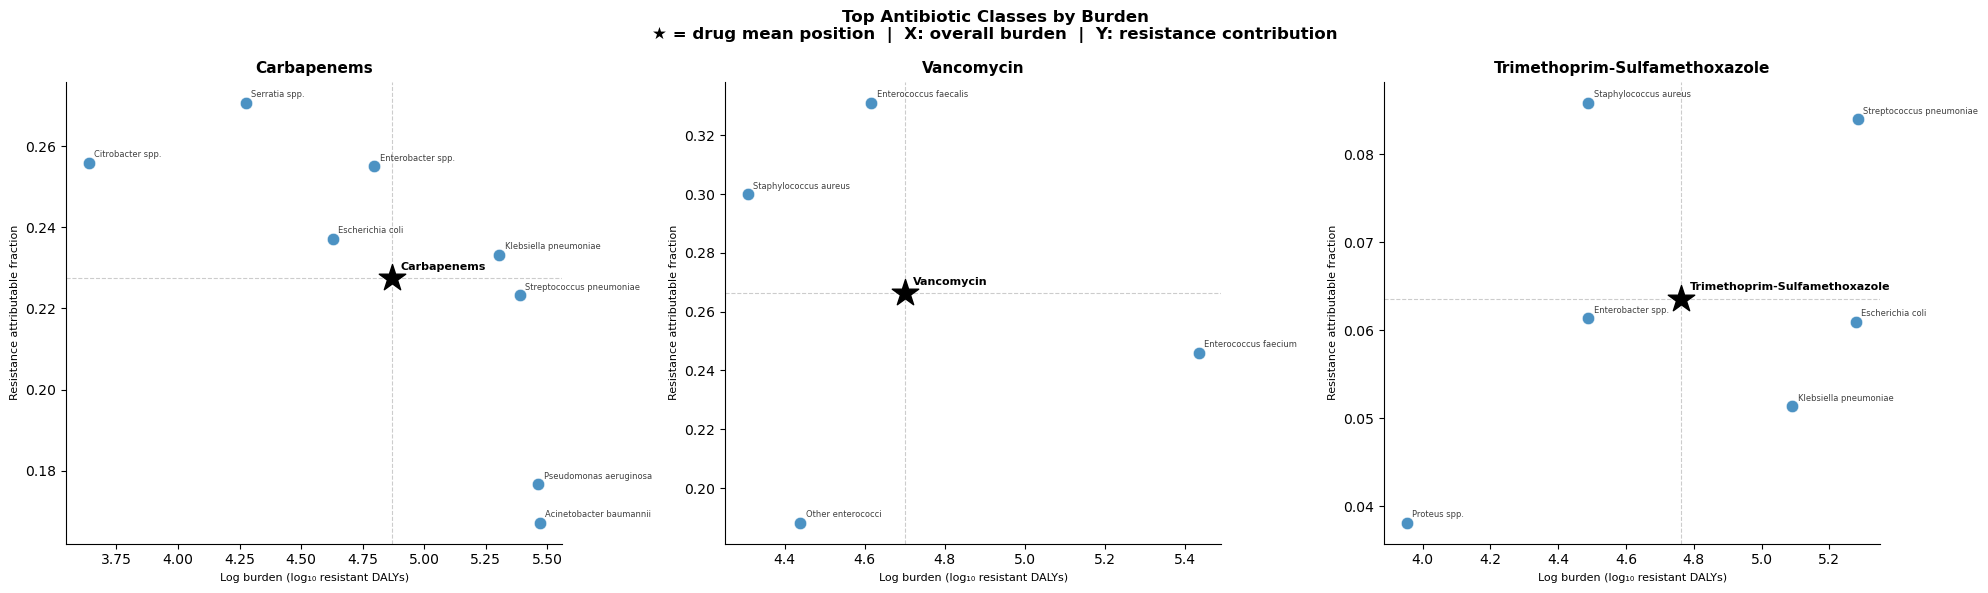

In [4]:
top_drugs = [
    "Carbapenems",
    "Vancomycin",
    "Trimethoprim-Sulfamethoxazole"
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, drug in enumerate(top_drugs):
    ax = axes[i]
    
    drug_df = feature_matrix[feature_matrix['antibiotic_class'] == drug].copy()
    
    drug_x = drug_df['log_burden'].mean()
    drug_y = drug_df['resistance_attr_frac'].mean()
    
    ax.scatter(
        drug_df['log_burden'],
        drug_df['resistance_attr_frac'],
        s=80,
        alpha=0.8,
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )
    
    for _, row in drug_df.iterrows():
        ax.annotate(
            row['pathogen'],
            xy=(row['log_burden'], row['resistance_attr_frac']),
            fontsize=6,
            alpha=0.75,
            xytext=(4, 4),
            textcoords='offset points'
        )
    
    ax.scatter(drug_x, drug_y,
               marker='*', s=400, color='black', zorder=5)
    ax.annotate(drug, xy=(drug_x, drug_y),
                fontsize=8, fontweight='bold',
                xytext=(6, 6), textcoords='offset points')
    
    ax.axhline(drug_y, linestyle='--', color='gray', alpha=0.4, linewidth=0.8)
    ax.axvline(drug_x, linestyle='--', color='gray', alpha=0.4, linewidth=0.8)
    
    ax.set_title(f"{drug}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Log burden (log₁₀ resistant DALYs)", fontsize=8)
    ax.set_ylabel("Resistance attributable fraction", fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    "Top Antibiotic Classes by Burden\n"
    "★ = drug mean position  |  X: overall burden  |  Y: resistance contribution",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [5]:
top_row = drug_df.loc[drug_df['log_burden'].idxmax()]

print(f"Top for {drug}: "
      f"{top_row['pathogen']} "
      f"(log_burden={top_row['log_burden']:.2f}, "
      f"res_frac={top_row['resistance_attr_frac']:.2f})")

Top for Trimethoprim-Sulfamethoxazole: Streptococcus pneumoniae (log_burden=5.28, res_frac=0.08)
